# Customer Lifetime Value Prediction

**Objective:** Estimate customer lifetime value for retention prioritization while separating prediction from causal impact.

This notebook uses a deterministic, domain-shaped demo dataset so the end-to-end regression workflow is executable without private data. Reported metrics describe this demo only.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic demo data


In [2]:
NUMERIC_FEATURES = ["orders_12m", "avg_order_value", "tenure_months", "return_rate", "support_tickets", "engagement_score"]
CATEGORICAL_VALUES = {
  "segment": [
    "consumer",
    "small_business",
    "enterprise"
  ],
  "acquisition_channel": [
    "search",
    "referral",
    "partner",
    "social"
  ]
}
CATEGORICAL_FEATURES = list(CATEGORICAL_VALUES)
TARGET = "lifetime_value"
N_ROWS = 1400

data = pd.DataFrame()
for i, name in enumerate(NUMERIC_FEATURES):
    center = 25 + 18 * i
    spread = 6 + 3 * i
    values = rng.normal(center, spread, N_ROWS)
    data[name] = np.maximum(values, 0).round(3)
for name, values in CATEGORICAL_VALUES.items():
    data[name] = rng.choice(values, size=N_ROWS)

numeric_signal = sum((i + 1) * (data[name] - data[name].mean()) / (data[name].std() + 1e-9) for i, name in enumerate(NUMERIC_FEATURES))
category_signal = sum(data[name].astype("category").cat.codes * (8 + 2 * i) for i, name in enumerate(CATEGORICAL_FEATURES))
nonlinear = 4.5 * np.sin(data[NUMERIC_FEATURES[0]] / (data[NUMERIC_FEATURES[0]].std() + 1e-9))
data["lifetime_value"] = 120 + 22 * numeric_signal + category_signal + nonlinear + rng.normal(0, 18, len(data))
data["lifetime_value"] = data["lifetime_value"].clip(lower=1)


for column in NUMERIC_FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=18, replace=False)
    data.loc[missing_rows, column] = np.nan

print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())


Dataset shape: 1,400 rows × 9 columns


,orders_12m,avg_order_value,tenure_months,return_rate,support_tickets,engagement_score,segment,acquisition_channel,lifetime_value
0,26.828,53.643,57.885,66.864,127.417,84.325,small_business,social,108.762180
1,18.760,40.084,72.638,49.162,121.159,96.297,small_business,referral,23.927350
2,29.503,41.163,71.491,87.109,108.391,99.897,enterprise,partner,188.050552
3,30.643,38.575,49.217,110.801,103.812,110.636,consumer,social,292.306897
4,13.294,37.774,50.734,99.843,95.417,99.018,consumer,partner,1.000000


## 3. Data quality and exploratory analysis


,dtype,missing,missing_pct,unique
orders_12m,float64,18,1.29,1335
avg_order_value,float64,18,1.29,1352
tenure_months,float64,0,0.00,1373
return_rate,float64,0,0.00,1381
support_tickets,float64,0,0.00,1390
engagement_score,float64,0,0.00,1384
segment,object,0,0.00,3
acquisition_channel,object,0,0.00,4
lifetime_value,float64,0,0.00,1062


,count,mean,std,min,25%,50%,75%,max
orders_12m,1382.0,24.867,5.970,3.110,20.918,25.037,28.700,44.073
avg_order_value,1382.0,42.683,9.113,15.426,36.714,42.930,48.737,69.228
tenure_months,1400.0,61.092,11.844,28.007,52.846,61.051,68.899,102.449
return_rate,1400.0,78.869,14.860,31.845,68.610,79.053,88.414,128.065
support_tickets,1400.0,97.663,18.811,17.996,85.883,96.800,110.415,154.747
engagement_score,1400.0,114.543,20.528,51.656,100.929,114.073,127.970,199.542
lifetime_value,1400.0,170.085,164.977,1.000,5.950,136.925,269.444,870.240


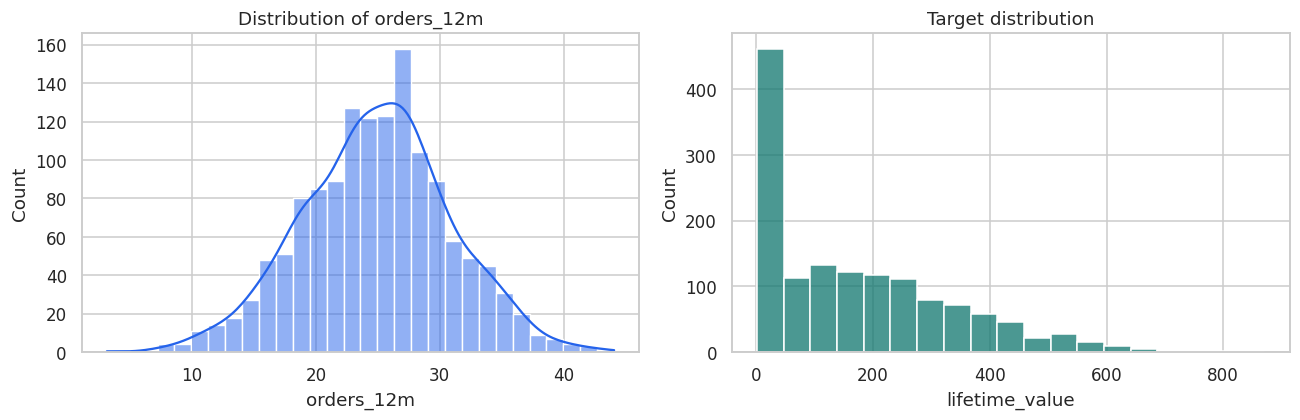

In [3]:
overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_pct": (100 * data.isna().mean()).round(2),
    "unique": data.nunique(dropna=False),
})
display(overview)
display(data[NUMERIC_FEATURES + [TARGET]].describe().T.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=data, x=NUMERIC_FEATURES[0], kde=True, ax=axes[0], color="#2563eb")
sns.histplot(data=data, x=TARGET, ax=axes[1], color="#0f766e")
axes[0].set_title(f"Distribution of {NUMERIC_FEATURES[0]}")
axes[1].set_title("Target distribution")
plt.tight_layout()
plt.show()


## 4. Leakage-safe preprocessing, baseline, and model comparison


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("numeric", numeric_pipe, NUMERIC_FEATURES), ("categorical", categorical_pipe, CATEGORICAL_FEATURES)])
models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Ridge Regression": Ridge(alpha=2.0),
    "Random Forest": RandomForestRegressor(n_estimators=180, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1),
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, estimator in models.items():
    candidate = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=1)
    comparison.append({"model": name, "cv_mae": -scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_mae").reset_index(drop=True)
display(comparison.round(3))


,model,cv_mae,cv_std
0,Ridge Regression,42.561,2.273
1,Random Forest,45.913,5.135
2,Median baseline,132.453,13.831


## 5. Holdout evaluation


Selected model: Ridge Regression
Holdout MAE: 42.837
Holdout RMSE: 56.791
Holdout R²: 0.8838


,actual,predicted
0,270.897,270.074
1,224.238,247.072
2,195.705,229.791
3,1.000,39.691
4,31.977,113.142
5,1.000,19.326
6,1.000,20.862
7,53.781,82.693
8,297.448,285.184
9,1.000,-106.200


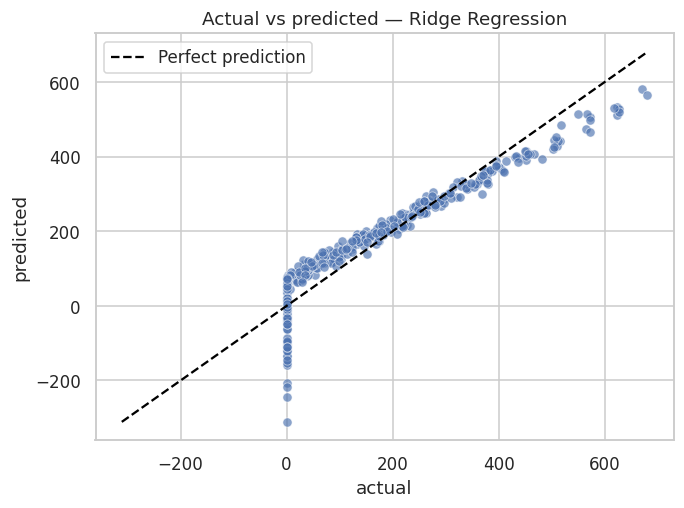

In [5]:
best_name = comparison.iloc[0]["model"]
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])]).fit(X_train, y_train)
predictions = best_pipeline.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Holdout MAE: {mean_absolute_error(y_test, predictions):.3f}")
print(f"Holdout RMSE: {mean_squared_error(y_test, predictions) ** 0.5:.3f}")
print(f"Holdout R²: {r2_score(y_test, predictions):.4f}")
evaluation = pd.DataFrame({"actual": y_test.to_numpy(), "predicted": predictions})
display(evaluation.head(10).round(3))
sns.scatterplot(data=evaluation, x="actual", y="predicted", alpha=0.65)
limits = [evaluation.min().min(), evaluation.max().max()]
plt.plot(limits, limits, "--", color="black", label="Perfect prediction")
plt.title(f"Actual vs predicted — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Permutation importance and diagnostics


,feature,importance_mean,importance_std
5,engagement_score,0.6539,0.0392
4,support_tickets,0.5330,0.0279
3,return_rate,0.3421,0.0191
2,tenure_months,0.2129,0.0166
1,avg_order_value,0.0676,0.0045
0,orders_12m,0.0168,0.0047
7,acquisition_channel,0.0029,0.0023
6,segment,0.0025,0.0008


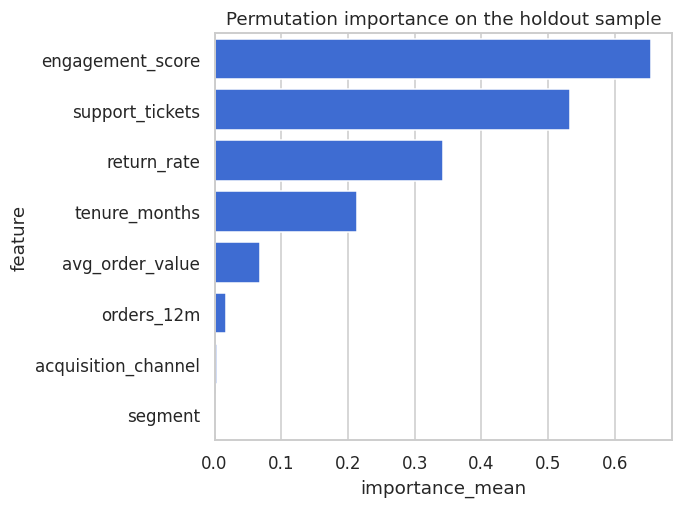

In [6]:
from sklearn.inspection import permutation_importance

sample_size = min(500, len(X_test))
X_explain = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_explain = y_test.loc[X_explain.index]
importance = permutation_importance(best_pipeline, X_explain, y_explain, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance_df.round(4))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#2563eb")
plt.title("Permutation importance on the holdout sample")
plt.tight_layout()
plt.show()


## 7. Limitations and next steps

- Replace demo data with licensed, representative, versioned production data.
- Review target definition, leakage risks, subgroup behavior, calibration, and domain error costs.
- Add uncertainty estimates, drift monitoring, human-review policies, and retraining criteria before deployment.
- Treat feature importance as model behavior—not causality.
